In [249]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [250]:
def compute_spectra(bins, v, ndft):
    sfdr = np.zeros(len(bins))
    hd3 = np.zeros(len(bins))
    spec_dbv_out = np.zeros((len(bins), ndft//2+1))
    for i in bins:
        y = v[i-1, :]
        y = y[:-1]
        relative_error = (y[-1]-y[-1-ndft])/y[-1]
        print(relative_error)
        y = y[-ndft:]
        spec = np.fft.rfft(y)
        spec_dbv = 20*np.log10(np.abs(spec)/(ndft/2))
        spec_dbv_out[i-1, :] = spec_dbv
        sfdr[i-1] = spec_dbv[i] - np.max(np.delete(spec_dbv, [0, i]))
        hd3[i-1] = spec_dbv[i] - spec_dbv[get_third_harmonic_bin(i, ndft)]
    return sfdr, hd3, spec_dbv_out

In [251]:
def get_third_harmonic_bin(i, ndft):
    """
    Finds the 3rd harmonic bin for a real-valued signal.
    i: fundamental bin index
    nfft: total number of FFT points
    """
    # Step 1: Wrap around the sampling frequency
    wrapped_bin = (3 * i) % ndft
    
    # Step 2: Fold back if it's above Nyquist
    if wrapped_bin > ndft // 2:
        harmonic_bin = ndft - wrapped_bin
    else:
        harmonic_bin = wrapped_bin
        
    return int(harmonic_bin)

In [252]:
df1 = pd.read_csv('./xschem/simulation/tb_boot_bottom_track.txt', sep='\\s+')
df2 = pd.read_csv('./xschem/simulation/tb_boot_bottom.txt', sep='\\s+')
df1

,time,v(vi),v(vc)
0,1.100000e-09,0.322019,0.321802
1,3.100000e-09,0.361584,0.361366
2,5.100000e-09,0.398627,0.398422
3,7.100000e-09,0.431632,0.431450
4,9.100000e-09,0.459248,0.459098
...,...,...,...
103,6.310000e-08,0.364990,0.364344
104,6.510000e-08,0.461392,0.460954
105,6.710000e-08,0.499938,0.499915
106,6.910000e-08,0.466813,0.467222


In [ ]:
# Parameters
fs = 500e6
ndft = 31
runs = 15
bins = np.arange(1, runs+1)

In [254]:
vi_track = np.reshape(df1['v(vi)'].values, [runs, len(df1)//runs])
vo_track = np.reshape(df1['v(vc)'].values, [runs, len(df1)//runs])
vi = np.reshape(df2['v(vi)'].values, [runs, len(df2)//runs])
vo = np.reshape(df2['v(vo)'].values, [runs, len(df2)//runs])

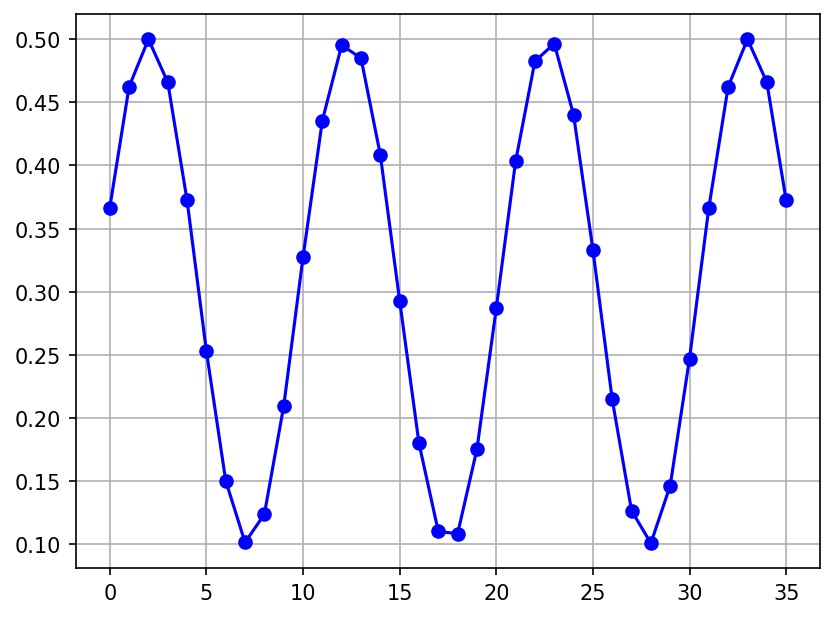

In [255]:
plt.plot(vo[2, :], "b-o")
plt.grid()
plt.show()

In [256]:
hd3_vi_track = compute_spectra(bins, vi_track, ndft)[1]
hd3_vo_track = compute_spectra(bins, vo_track, ndft)[1]
hd3_vi = compute_spectra(bins, vi, ndft)[1]
hd3_vo = compute_spectra(bins, vo, ndft)[1]

9.267160489918713e-10
9.835340952359899e-09
-7.711874541078302e-09
7.185077149453399e-09
-3.0112429757962876e-09
-8.561238212469949e-10
1.3527328366773149e-08
-1.4002570531818612e-08
4.392288457057431e-08
-6.017900295583546e-09
-2.2474540528421038e-08
3.326831571210274e-07


In [257]:
# Analytical data
vov = 0.734
vm = 0.20
fs = 500e6
fin = bins*fs/ndft
c = 5e-12
cb = 1e-12
cp =  100e-15 + 2e-15
gds = 151e-3
fbw=1/(2*np.pi*c/gds)
hd3_calc = -20*np.log10((1/2)*fin/fbw*(vm/vov)**2 *(cp/cb)**2)
print(fbw/1e6)

4806.479281375239


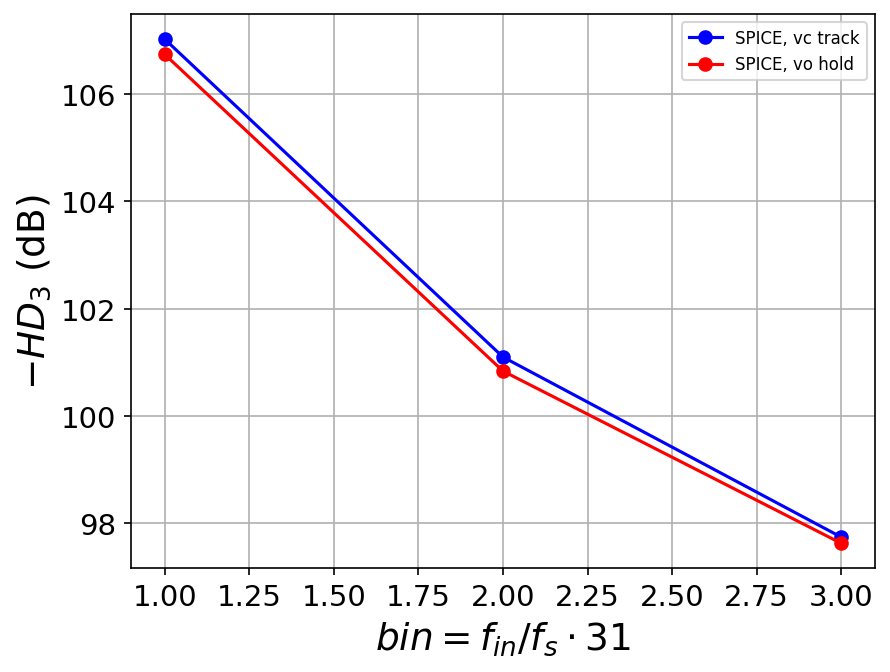

In [258]:
plt.rcParams['figure.dpi'] = 150
#plt.plot(bins, hd3_calc, "g--", label='Track-mode analysis')
#plt.plot(bins, hd3_vi_track, "b--", label='vi track')
#plt.plot(bins, hd3_vi, "r--", label='vi hold')
plt.plot(bins, hd3_vo_track, "b-o", label='SPICE, vc track')
plt.plot(bins, hd3_vo, "r-o", label='SPICE, vo hold')
    
plt.grid()
plt.xlabel("$bin = f_{in}/f_s \\cdot 31$", fontsize=18)
plt.ylabel("$-HD_3$ (dB)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.ylim(50, 140)
plt.grid(True)
plt.legend(fontsize=8)
plt.show()

In [259]:
spec_dbv_out = compute_spectra(bins, vo, ndft)[2]

plt.plot(spec_dbv_out[3, :], "b-o", label='spec')
plt.grid()
plt.xlabel("$bin = f_{in}/f_s \\cdot 31$", fontsize=18)
plt.ylabel("Magnitude (dBV)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.ylim(25, 72)
plt.grid(True)
plt.legend()
plt.show()


-6.017900295583546e-09
-2.2474540528421038e-08
3.326831571210274e-07


IndexError: index 3 is out of bounds for axis 0 with size 3